# 2. Nettoyage et Préprocessing des Avis d'Assurance

Ce notebook nettoie et prépare les données pour les analyses suivantes.

In [1]:
import os
import re
import warnings

import matplotlib.pyplot as plt
import nltk
import pandas as pd
import spacy
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer
from spellchecker import SpellChecker
from tqdm.auto import tqdm

from config import *

In [2]:
warnings.filterwarnings('ignore')
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)

True

## 2.1 Chargement des données

In [3]:
df = pd.read_csv(DATA_PATH)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34435 entries, 0 to 34434
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   note              24104 non-null  float64
 1   auteur            34434 non-null  object 
 2   avis              34435 non-null  object 
 3   assureur          34435 non-null  object 
 4   produit           34435 non-null  object 
 5   type              34435 non-null  object 
 6   date_publication  34435 non-null  object 
 7   date_exp          34435 non-null  object 
 8   avis_en           34433 non-null  object 
 9   avis_cor          435 non-null    object 
 10  avis_cor_en       431 non-null    object 
dtypes: float64(1), object(10)
memory usage: 2.9+ MB


## 2.2 Suppression des doublons et valeurs manquantes

In [5]:
nb_ligne_before = len(df)
nb_ligne_before

34435

In [6]:
df = df.drop_duplicates()

In [7]:
len(df)

34430

In [8]:
df = df.dropna(subset=[RATING_COL])

In [9]:
len(df)

24100

## 2.3 Création de la colonne sentiment

In [10]:
def get_sentiment(stars):
    if stars <= 2:
        return 'négatif'
    elif stars == 3:
        return 'neutre'
    else:
        return 'positif'

In [11]:
df[SENTIMENT_COL] = df[RATING_COL].apply(get_sentiment)
print(df[SENTIMENT_COL].value_counts())

sentiment
négatif    10987
positif     9731
neutre      3382
Name: count, dtype: int64


### Distribution des sentiments

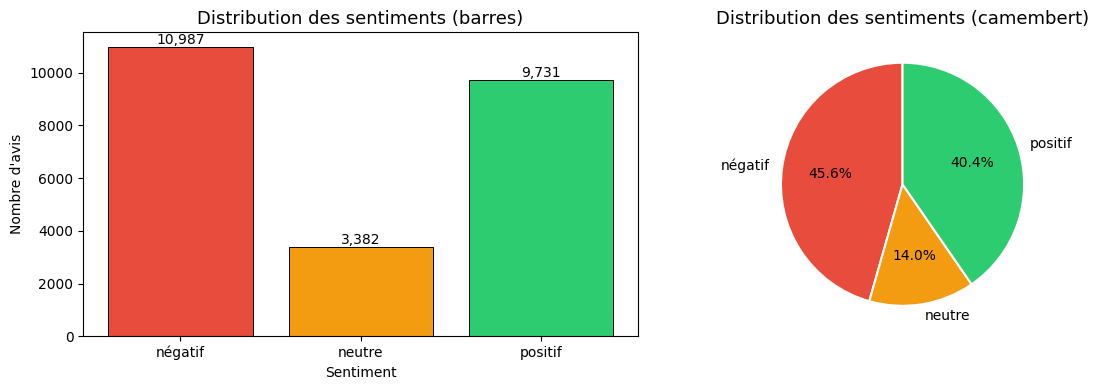

In [12]:
label_order = ['négatif', 'neutre', 'positif']
counts = df[SENTIMENT_COL].value_counts().reindex(label_order).fillna(0).astype(int)
colors = ['#e74c3c', '#f39c12', '#2ecc71']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(counts.index, counts.values, color=colors, edgecolor='black', linewidth=0.7)
axes[0].set_title('Distribution des sentiments (barres)', fontsize=13)
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel("Nombre d'avis")
for i, (lab, val) in enumerate(zip(counts.index, counts.values)):
    axes[0].text(i, val + counts.max() * 0.01, f'{val:,}', ha='center', fontsize=10)

axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Distribution des sentiments (camembert)', fontsize=13)

plt.tight_layout()
plt.show()

## 2.4 Normalisation du texte

In [13]:
def normalize_text(text):
    """Normalisation de base pour le français"""
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'\b\d+\b', '', text)
    text = text.replace('\u2019', "'").replace('\u2018', "'")
    text = re.sub(r"[^a-zàâäéèêëîïôöùûüçœæ\s']", ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [14]:
sample = "J'ai eu une MAUVAISE expérience avec cette assurance ! Ils ont refusé mon dossier. www.assurance.fr"
print("Original :", sample)
print("Normalisé :", normalize_text(sample))

Original : J'ai eu une MAUVAISE expérience avec cette assurance ! Ils ont refusé mon dossier. www.assurance.fr
Normalisé : j'ai eu une mauvaise expérience avec cette assurance ils ont refusé mon dossier


## 2.5 Suppression des stopwords

In [15]:
keep_words = {'ne', 'pas', 'jamais', 'rien', 'personne', 'aucun', 'aucune', 'sans', 'ni', 'non'}
stopwords_fr = set(stopwords.words('french')) - keep_words

In [16]:
def remove_stopwords(text):
    """Supprime les stopwords français."""
    tokens = text.split()
    return ' '.join([w for w in tokens if w not in stopwords_fr])

In [17]:
sample_clean = normalize_text(sample)
print("Avec stopwords    :", sample_clean)
print("Sans stopwords    :", remove_stopwords(sample_clean))

Avec stopwords    : j'ai eu une mauvaise expérience avec cette assurance ils ont refusé mon dossier
Sans stopwords    : j'ai mauvaise expérience cette assurance refusé dossier


## 2.6 Correction orthographique

In [18]:
spell = SpellChecker(language='fr')

In [19]:
def correct_spelling(text):
    """Correction orthographique française."""
    return ' '.join(
        [spell.correction(word) or word if len(word) > 2 and word.isalpha() else word for word in text.split()])

In [20]:
test_txt = "l'assurence a refusé mon dossié sans explication"
print("Original  :", test_txt)
print("Corrigé   :", correct_spelling(test_txt))

Original  : l'assurence a refusé mon dossié sans explication


Corrigé   : l'assurence a refusé mon dossier sans explication


## 2.7 Lemmatisation avec spaCy

In [21]:
nlp = spacy.load('fr_core_news_sm', disable=['parser', 'ner'])

In [22]:
def lemmatize_text(text):
    """Lemmatise le texte français avec spaCy, en conservant les mots de négation."""
    doc = nlp(str(text)[:500])
    return ' '.join([
        token.lemma_ for token in doc
        if (not token.is_stop or token.text in keep_words) and not token.is_punct and len(token.text) > 2
    ])

In [23]:
test_sentence = "l'assurance a refusé de rembourser mes frais médicaux sans aucune explication"
print("Original  :", test_sentence)
print("Lemmatisé :", lemmatize_text(test_sentence))

Original  : l'assurance a refusé de rembourser mes frais médicaux sans aucune explication
Lemmatisé : assurance refuser rembourser frais médical sans aucun explication


## 2.8 Pipeline de preprocessing complet

In [24]:
def preprocess_pipeline(text):
    """Pipeline complet de préprocessing pour le français."""
    if pd.isna(text) or str(text).strip() == '':
        return ''

    text = normalize_text(text)
    text = correct_spelling(text)
    text = remove_stopwords(text)
    text = lemmatize_text(text)

    return text

In [25]:
test_reviews = [
    "J'ai eu une terrible expérience avec cette compagnie d'assurance ! Ils ont refusé mon dossier sans raison.",
    "Très bonne couverture et prix compétitifs. Le service client a été très réactif.",
    "Résiliation de mon contrat après 3 mois. La prime a augmenté sans préavis."
]

print("Test du pipeline\n")
for review in test_reviews:
    cleaned = preprocess_pipeline(review)
    print(f"Original : {review[:100]}")
    print(f"Nettoyé  : {cleaned[:100]}")
    print()

Test du pipeline

Original : J'ai eu une terrible expérience avec cette compagnie d'assurance ! Ils ont refusé mon dossier sans r
Nettoyé  : terrible expérience compagnie assurance refuser dossier sans raison

Original : Très bonne couverture et prix compétitifs. Le service client a été très réactif.
Nettoyé  : bon couvertur prix compétitif service client réactif

Original : Résiliation de mon contrat après 3 mois. La prime a augmenté sans préavis.
Nettoyé  : résiliation contrat mois prime augmenter sans préavis



In [26]:
if os.path.exists(DATA_CLEAN) and CLEAN_COL in pd.read_csv(DATA_CLEAN, nrows=1).columns:
    print(f"Pipeline déjà effectuée — chargement de {DATA_CLEAN} .")
    df = pd.read_csv(DATA_CLEAN)
else:
    tqdm.pandas(desc="application du pipeline", bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}]")

    df[CLEAN_COL] = df[TEXT_COL].progress_apply(preprocess_pipeline)
    print(f"Preprocessing terminé sur {len(df)} avis !")

Pipeline déjà effectuée — chargement de /Users/amaitre/prive/4_ECOLE/S8/NLP/sentiment_analysis_model/data/processed/reviews_clean.csv .


In [27]:
df[LENGTH_COL] = df[TEXT_COL].str.len()
df['avis_clean_len'] = df[CLEAN_COL].str.len()
df['nb_mots'] = df[CLEAN_COL].str.split().str.len()

print(f"Longueur moyenne originale : {df[LENGTH_COL].mean():.0f} car.")
print(f"Longueur moyenne nettoyée  : {df['avis_clean_len'].mean():.0f} car.")
print(f"Mots moyens (nettoyé)      : {df['nb_mots'].mean():.1f}")

Longueur moyenne originale : 349 car.


Longueur moyenne nettoyée  : 169 car.
Mots moyens (nettoyé)      : 21.6


## 2.9 Analyse post-nettoyage

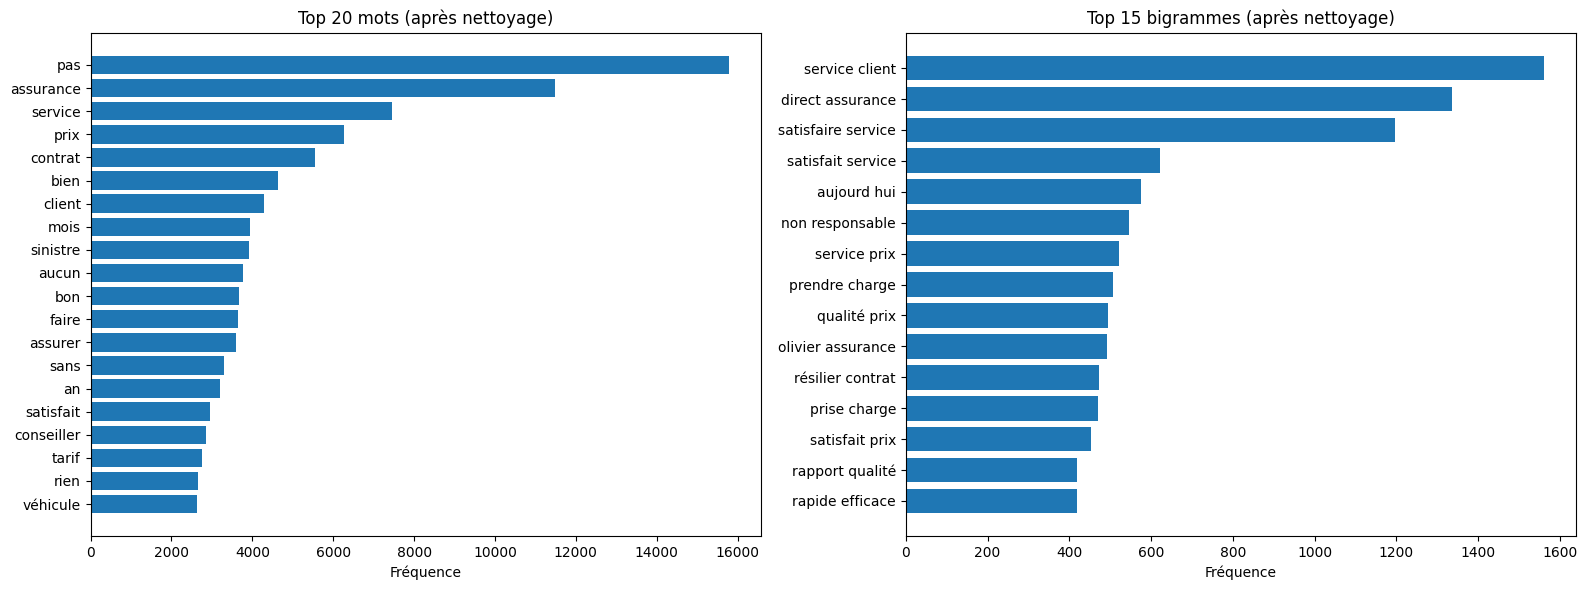

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

vectorizer_uni = CountVectorizer(max_features=30, ngram_range=(1, 1))
X_uni = vectorizer_uni.fit_transform(df[CLEAN_COL].fillna(''))
word_freq = pd.DataFrame({
    'word': vectorizer_uni.get_feature_names_out(),
    'count': X_uni.toarray().sum(axis=0)
}).sort_values('count', ascending=True)

axes[0].barh(word_freq['word'].tail(20), word_freq['count'].tail(20))
axes[0].set_title('Top 20 mots (après nettoyage)')
axes[0].set_xlabel('Fréquence')

# Bigrammes
vectorizer_bi = CountVectorizer(max_features=20, ngram_range=(2, 2))
X_bi = vectorizer_bi.fit_transform(df[CLEAN_COL].fillna(''))
bigram_freq = pd.DataFrame({
    'bigram': vectorizer_bi.get_feature_names_out(),
    'count': X_bi.toarray().sum(axis=0)
}).sort_values('count', ascending=True)

axes[1].barh(bigram_freq['bigram'].tail(15), bigram_freq['count'].tail(15))
axes[1].set_title('Top 15 bigrammes (après nettoyage)')
axes[1].set_xlabel('Fréquence')

plt.tight_layout()
plt.show()

## 2.10 Export des données nettoyées

In [29]:
df.to_csv(DATA_CLEAN, index=False)

In [30]:
df.head()

,note,auteur,avis,assureur,produit,type,date_publication,date_exp,avis_en,avis_cor,avis_cor_en,sentiment,avis_clean,avis_taille,avis_clean_len,nb_mots
0,4.0,audurier-c-136272,La personne au téléphone était Clair et sympat...,L'olivier Assurance,auto,train,06/10/2021,01/10/2021,The person on the phone was clear and friendly...,NaN,NaN,positif,personne téléphoner clair sympathique bien exp...,167,110.0,12.0
1,4.0,paul-a-122970,"Satisfait.\n\nRéactivité, simplicité. Prix att...",APRIL Moto,moto,train,09/07/2021,01/07/2021,"Satisfied.\n\nReactivity, simplicity. Attracti...",NaN,NaN,positif,satisfait réactivité simplicité prix attractif...,163,120.0,14.0
2,1.0,kitty-38517,"Assureur à fuir, n assure pas ses responsabili...",SwissLife,vie,train,15/10/2020,01/10/2020,"Insurer to flee, does not ensure its responsib...",NaN,NaN,négatif,assureur fuir assurer pas responsabilité agent...,213,144.0,19.0
3,1.0,laure97134-87907,Voilà 3 mois que la GMF me fait attendre pour ...,GMF,habitation,train,03/03/2020,01/03/2020,The GMF has been waiting for a water damage fo...,NaN,NaN,négatif,mois attendre dégât eau contrat,124,31.0,5.0
4,3.0,bourouane-l-129916,Je suis bien avec cet assurance.elle est prati...,L'olivier Assurance,auto,train,28/08/2021,01/08/2021,I am good with this insurance. She is practica...,NaN,NaN,neutre,bien assurance pratique cher trouver meurtre a...,170,104.0,13.0
